<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Correlation**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis (EDA). You will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.


## Objectives


In this lab, you will perform the following:


- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.


## Hands on Lab


##### Step 1: Install and Import Required Libraries


In [1]:
# Install the necessary libraries
!pip install pandas
!pip install matplotlib
!pip install seaborn

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 141.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 199.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 86.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 150.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 102.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 146.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


### Step 2: Load the Dataset


In [2]:
# Load the dataset from the given URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Display the first few rows to understand the structure of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>


**Task**: Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.


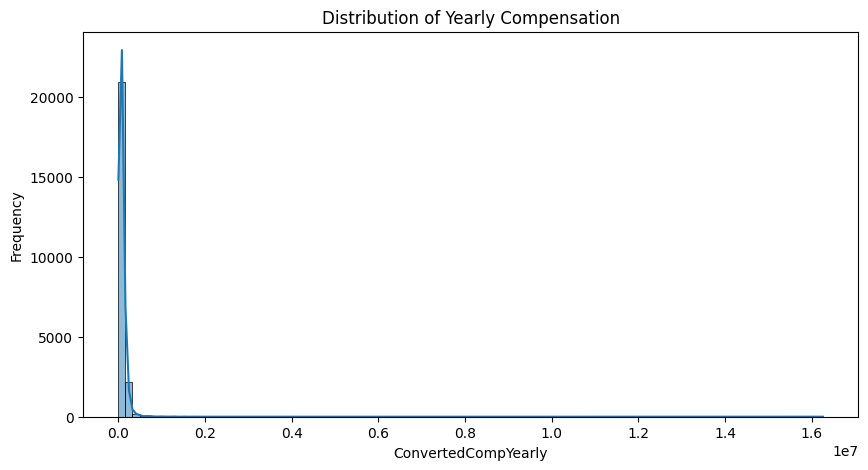

In [3]:
# Histogram with distribution

plt.figure(figsize=(10,5))

sns.histplot(df['ConvertedCompYearly'], bins=100, kde=True)

plt.title('Distribution of Yearly Compensation')
plt.xlabel('ConvertedCompYearly')
plt.ylabel('Frequency')

plt.show()

In [4]:
# Summary to support interpretation

df['ConvertedCompYearly'].describe()

count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64

<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>


**Task**: Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."


In [5]:
# Filter full-time employed respondents and compute median compensation

median_comp = df.loc[
    df['Employment'] == 'Employed, full-time',
    'ConvertedCompYearly'
].median()

print("Median compensation (full-time employed):", median_comp)

Median compensation (full-time employed): 69814.0

<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>


Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.



In [6]:
## Write your code here

!pip install country_converter

In [7]:
import logging
import country_converter as coco

# Get the logger used internally by country_converter
coco_logger = logging.getLogger("country_converter")

# Silence warnings (only critical errors will appear)
coco_logger.setLevel(logging.CRITICAL)

# Optional: prevent propagation to root logger
coco_logger.propagate = False

In [8]:
# Creating a new column with short country name based on the country column

df['Std_Country'] = coco.convert(
    names=df['Country'],
    to='name_short',
    not_found=None
)

In [9]:
# Creating a new column with continents based on the country column

df['Continent'] = coco.convert(
    names=df['Country'],
    to='continent',
    not_found=None
)

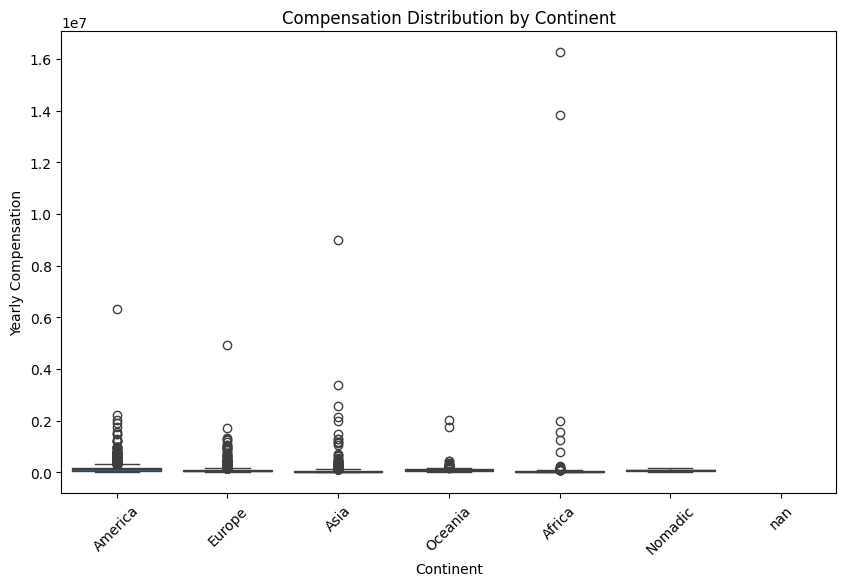

In [16]:
# Boxplot by continent or region

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Continent',
    y='ConvertedCompYearly'
)

plt.title('Compensation Distribution by Continent')
plt.xlabel('Continent')
plt.ylabel('Yearly Compensation')

plt.xticks(rotation=45)
plt.show()

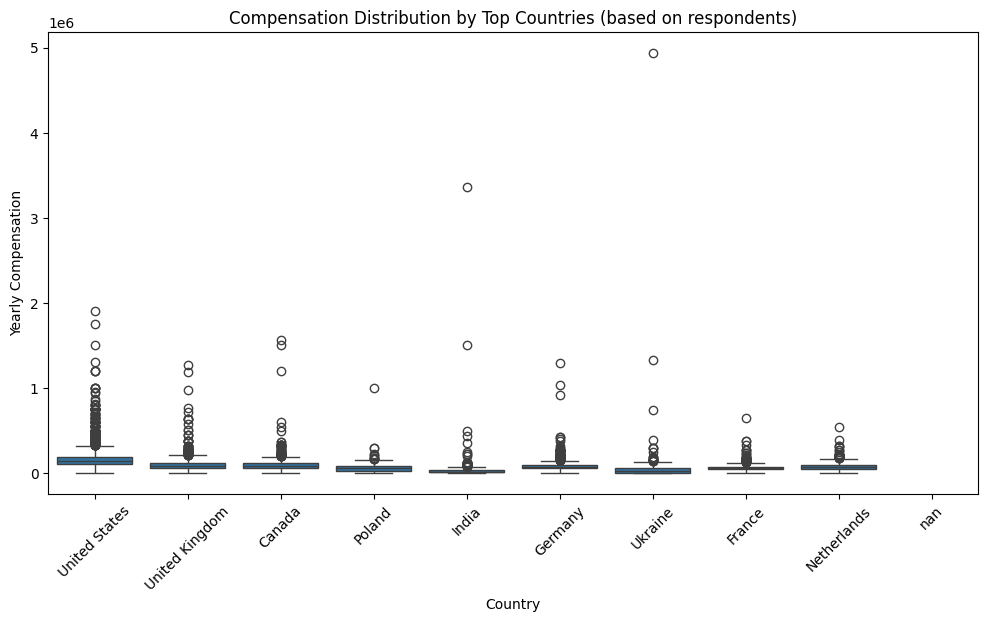

In [17]:
# Boxplot now by countries, avoid clutter by selecting top N countries by respondents:

top_countries = df['Std_Country'].value_counts().head(10).index

df_top = df[df['Std_Country'].isin(top_countries)]

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_top,
    x='Std_Country',
    y='ConvertedCompYearly'
)

plt.title('Compensation Distribution by Top Countries (based on respondents)')
plt.xlabel('Country')
plt.ylabel('Yearly Compensation')

plt.xticks(rotation=45)
plt.show()

<h3>Step 6: Removing Outliers from the Dataset</h3>


**Task**: Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.


In [18]:
# Identify outliers in the ConvertedCompYearly column using the IQR method.

Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['ConvertedCompYearly'] < lower_bound) | 
              (df['ConvertedCompYearly'] > upper_bound)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", outliers.shape[0])


Q1: 32712.0
Q3: 107971.5
IQR: 75259.5
Lower bound: -80177.25
Upper bound: 220860.75
Number of outliers: 978

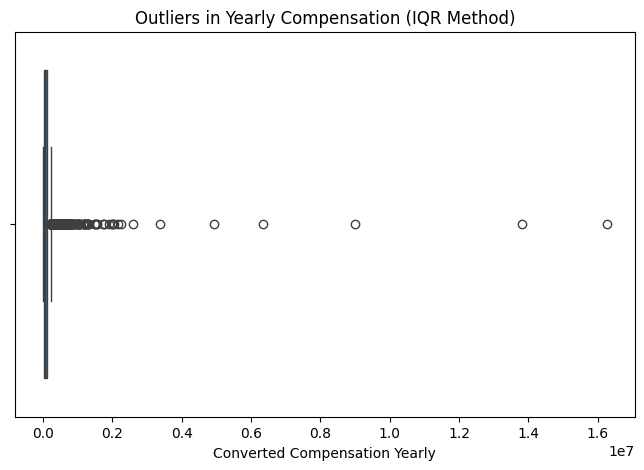

In [19]:
# Visualization with boxplot

plt.figure(figsize=(8,5))

sns.boxplot(x=df['ConvertedCompYearly'])

plt.title('Outliers in Yearly Compensation (IQR Method)')
plt.xlabel('Converted Compensation Yearly')

plt.show()

In [20]:
# IQR-based outlier removal for ConvertedCompYearly

Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = df[
    (df['ConvertedCompYearly'] >= lower_bound) &
    (df['ConvertedCompYearly'] <= upper_bound)
]

print("Original dataset size:", df.shape)
print("Clean dataset size (no outliers):", df_no_outliers.shape)
print("Rows removed:", df.shape[0] - df_no_outliers.shape[0])

Original dataset size: (65437, 116)
Clean dataset size (no outliers): (22457, 116)
Rows removed: 42980

<h3>Step 7: Finding Correlations Between Key Variables</h3>


**Task**: Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.


In [21]:
# Correlation matrix using the clean dataset free of outliers on ConvertedCompYearly

corr_df = df_no_outliers[
    ['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']
].dropna()

corr_matrix = corr_df.corr()

corr_matrix

,ConvertedCompYearly,WorkExp,JobSatPoints_1
ConvertedCompYearly,1.000000,0.406993,-0.059643
WorkExp,0.406993,1.000000,-0.032388
JobSatPoints_1,-0.059643,-0.032388,1.000000


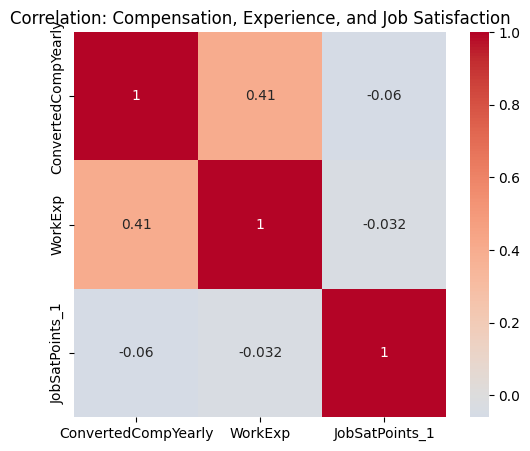

In [22]:
# Heatmap Visualization

plt.figure(figsize=(6,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation: Compensation, Experience, and Job Satisfaction')
plt.show()

<h3>Step 8: Scatter Plot for Correlations</h3>


**Task**: Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.


In [23]:
## Scatterplots for specific correlations

# Use cleaned dataset (already removed outliers)
df_scatter = df_no_outliers[['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']].dropna()

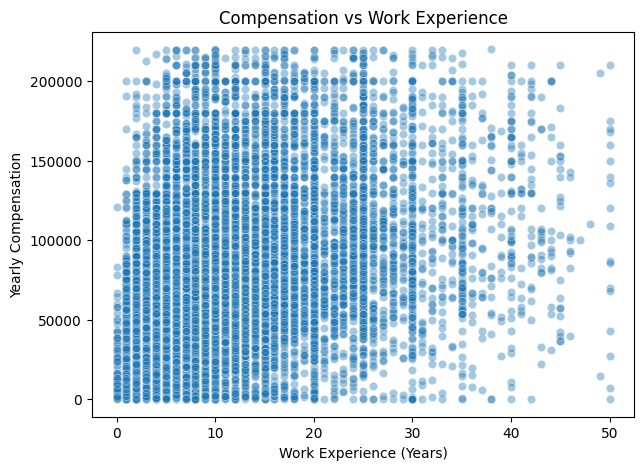

In [24]:
# Scatter: Compensation vs Work Experience

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df_scatter,
    x='WorkExp',
    y='ConvertedCompYearly',
    alpha=0.4
)

plt.title('Compensation vs Work Experience')
plt.xlabel('Work Experience (Years)')
plt.ylabel('Yearly Compensation')

plt.show()

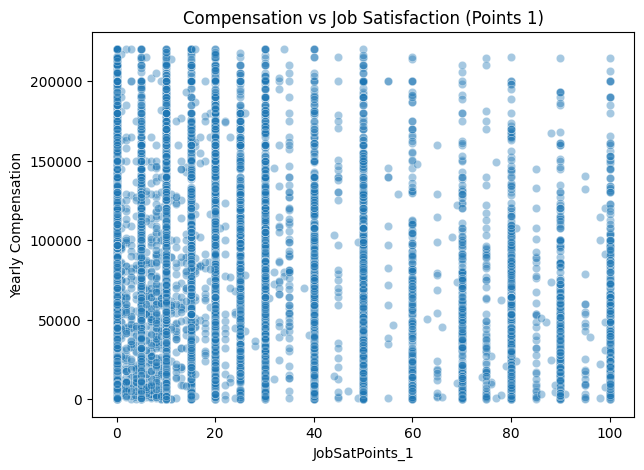

In [25]:
# Scatter: Compensation vs Job Satisfaction Points

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df_scatter,
    x='JobSatPoints_1',
    y='ConvertedCompYearly',
    alpha=0.4
)

plt.title('Compensation vs Job Satisfaction (Points 1)')
plt.xlabel('JobSatPoints_1')
plt.ylabel('Yearly Compensation')

plt.show()

<h3>Summary</h3>


In this lab, you practiced essential skills in correlation analysis by:

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

By following these steps, you have developed a solid foundation for analyzing relationships within the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
